# 🌦️ Weather Data Pipeline using Python

### End-to-End Weather Data Collection, Processing, and Analysis

**Author:** Vishnu Anilkumar
**Tools & Technologies:** Python, Pandas, NumPy, Requests, Matplotlib, Seaborn, Jupyter Notebook  
**Project Type:** Data Engineering | Data Analytics

---

## 📖 Project Overview

This project demonstrates the development of an end-to-end weather data pipeline using Python. Weather data is collected from a public API, transformed into a structured format, cleaned, and analyzed to extract meaningful insights. The processed dataset is then stored for future reporting, visualization, or machine learning applications.

The project follows a typical data pipeline workflow used in real-world data engineering and analytics projects, showcasing the complete journey from data acquisition to data preparation and exploratory analysis.

---

## 🎯 Project Objectives

- Retrieve real-time weather data from an API.
- Transform raw JSON data into a structured DataFrame.
- Clean and preprocess the dataset.
- Perform exploratory data analysis (EDA).
- Visualize important weather patterns and trends.
- Export the cleaned dataset for downstream analytics and reporting.

In [1]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="weather_project"
)

query = "SELECT * FROM weather"
df = pd.read_sql(query, connection)
connection.close()

print(f"Loaded {len(df)} weather records")
df.head()

Loaded 100 weather records


C:\Users\vishn\AppData\Local\Temp\ipykernel_13952\937761952.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,id,city,temperature,humidity,description,date_time
0,4,Thrissur,28.0,80,Patchy rain nearby,2026-07-29 14:05:08
1,5,Kochi,29.0,71,Patchy rain nearby,2026-07-29 14:05:10
2,6,Bangalore,27.0,52,Patchy rain nearby,2026-07-29 14:05:12
3,7,Chennai,35.0,44,Partly Cloudy,2026-07-29 14:05:14
4,8,Mumbai,29.0,81,Light rain shower,2026-07-29 14:05:17


In [2]:
df.head(10)

,id,city,temperature,humidity,description,date_time
0,4,Thrissur,28.0,80,Patchy rain nearby,2026-07-29 14:05:08
1,5,Kochi,29.0,71,Patchy rain nearby,2026-07-29 14:05:10
2,6,Bangalore,27.0,52,Patchy rain nearby,2026-07-29 14:05:12
3,7,Chennai,35.0,44,Partly Cloudy,2026-07-29 14:05:14
4,8,Mumbai,29.0,81,Light rain shower,2026-07-29 14:05:17
5,9,Delhi,36.0,44,Partly Cloudy,2026-07-29 14:05:19
6,10,Hyderabad,24.0,88,Light rain,2026-07-29 14:05:21
7,11,Pune,27.0,74,Patchy rain nearby,2026-07-29 14:05:23
8,12,Kolkata,32.0,63,Light rain shower,2026-07-29 14:05:25
9,13,Ahmedabad,32.0,57,Patchy rain nearby,2026-07-29 14:05:28


In [3]:
print("=" * 60)
print("📈 WEATHER DATA SUMMARY")
print("=" * 60)

print(f"\n📊 Total records: {len(df)}")
print(f"🌍 Unique cities: {df['city'].nunique()}")
print(f"\n🌡️ TEMPERATURE:")
print(f"   Min: {df['temperature'].min()}°C")
print(f"   Max: {df['temperature'].max()}°C")
print(f"   Average: {df['temperature'].mean():.1f}°C")

print(f"\n💧 HUMIDITY:")
print(f"   Average: {df['humidity'].mean():.1f}%")

print(f"\n🌤️ WEATHER CONDITIONS:")
print(df['description'].value_counts())

📈 WEATHER DATA SUMMARY

📊 Total records: 100
🌍 Unique cities: 100

🌡️ TEMPERATURE:
   Min: 10.0°C
   Max: 43.0°C
   Average: 27.2°C

💧 HUMIDITY:
   Average: 62.5%

🌤️ WEATHER CONDITIONS:
description
Sunny                                  27
Patchy rain nearby                     26
Partly Cloudy                          12
Light rain shower                      12
Partly cloudy                           4
Overcast                                3
Patchy light drizzle                    2
Cloudy                                  2
Cloudy                                  2
Clear                                   2
Light rain                              1
Moderate rain at times                  1
Clear                                   1
Light drizzle                           1
Moderate rain                           1
Moderate or heavy rain with thunder     1
Severe sandstorm                        1
Haze                                    1
Name: count, dtype: int64


In [4]:
print("\n🔥 TOP 10 HOTTEST CITIES:")
hottest = df.nlargest(10, 'temperature')[['city', 'temperature', 'humidity']]
print(hottest.to_string(index=False))


🔥 TOP 10 HOTTEST CITIES:
     city  temperature  humidity
   Kuwait         43.0         9
  Baghdad         40.0        12
 Ludhiana         39.0        38
Ghaziabad         38.0        43
     Doha         38.0        27
  Lucknow         37.0        41
Faridabad         37.0        42
    Dubai         37.0        45
Abu Dhabi         37.0        50
    Delhi         36.0        44


In [5]:
print("\n❄️ TOP 10 COLDEST CITIES:")
coldest = df.nsmallest(10, 'temperature')[['city', 'temperature', 'humidity']]
print(coldest.to_string(index=False))


❄️ TOP 10 COLDEST CITIES:
        city  temperature  humidity
Buenos Aires         10.0        84
   Melbourne         10.0        60
    Auckland         10.0        75
Johannesburg         11.0        59
   Cape Town         12.0        73
        Oslo         14.0        94
      Sydney         15.0        35
      Moscow         15.0        94
 Mexico City         15.0        82
     Nairobi         15.0        77


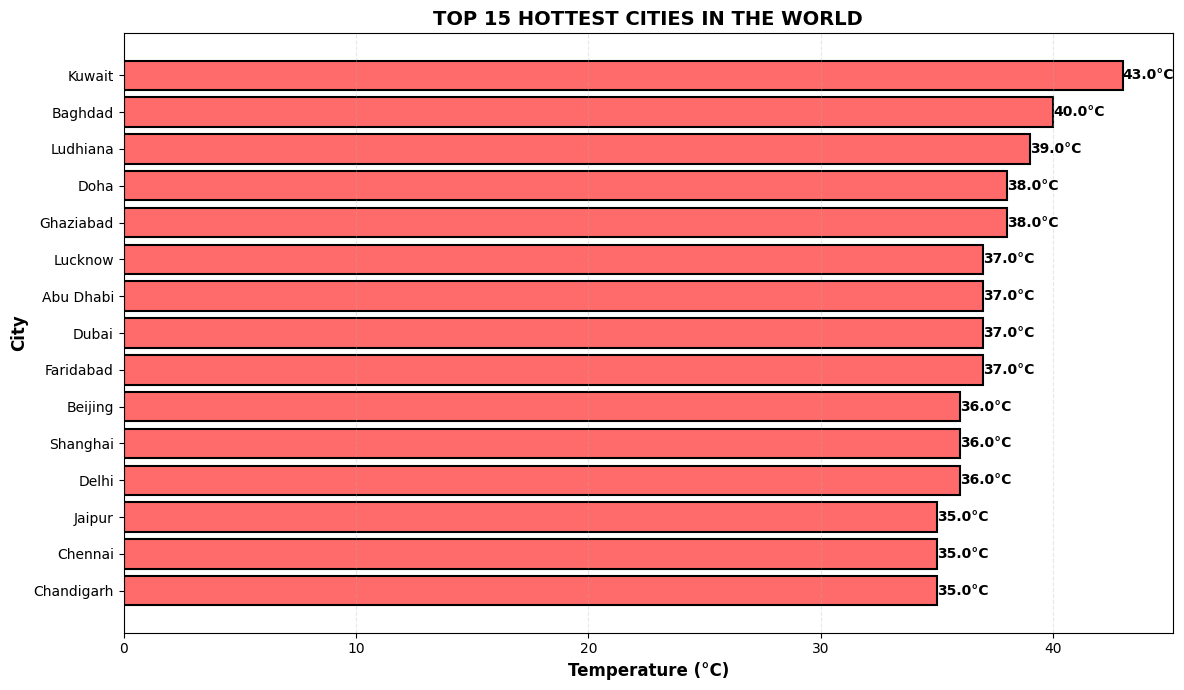

In [6]:
# CELL 2: Visualization 1 - Top 15 Hottest Cities (Bar Chart)
# ============================================================
 
plt.figure(figsize=(12, 7))
top_hot = df.nlargest(15, 'temperature')[['city', 'temperature']].sort_values('temperature')
bars = plt.barh(top_hot['city'], top_hot['temperature'], color='#ff6b6b', edgecolor='black', linewidth=1.5)
 
# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}°C', 
             ha='left', va='center', fontweight='bold', fontsize=10)
 
plt.xlabel('Temperature (°C)', fontweight='bold', fontsize=12)
plt.ylabel('City', fontweight='bold', fontsize=12)
plt.title('TOP 15 HOTTEST CITIES IN THE WORLD', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()
 

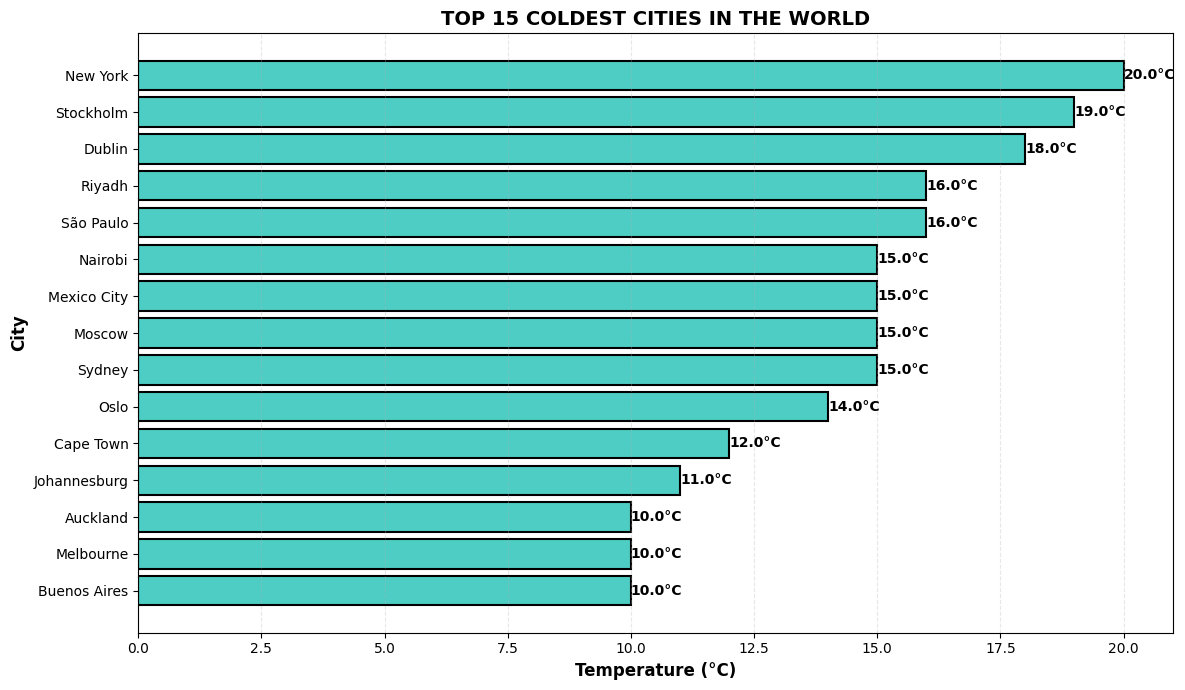

In [7]:
# CELL 3: Visualization 2 - Top 15 Coldest Cities (Bar Chart)
# ============================================================
 
plt.figure(figsize=(12, 7))
top_cold = df.nsmallest(15, 'temperature')[['city', 'temperature']].sort_values('temperature')
bars = plt.barh(top_cold['city'], top_cold['temperature'], color='#4ecdc4', edgecolor='black', linewidth=1.5)
 
# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}°C', 
             ha='left', va='center', fontweight='bold', fontsize=10)
 
plt.xlabel('Temperature (°C)', fontweight='bold', fontsize=12)
plt.ylabel('City', fontweight='bold', fontsize=12)
plt.title('TOP 15 COLDEST CITIES IN THE WORLD', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

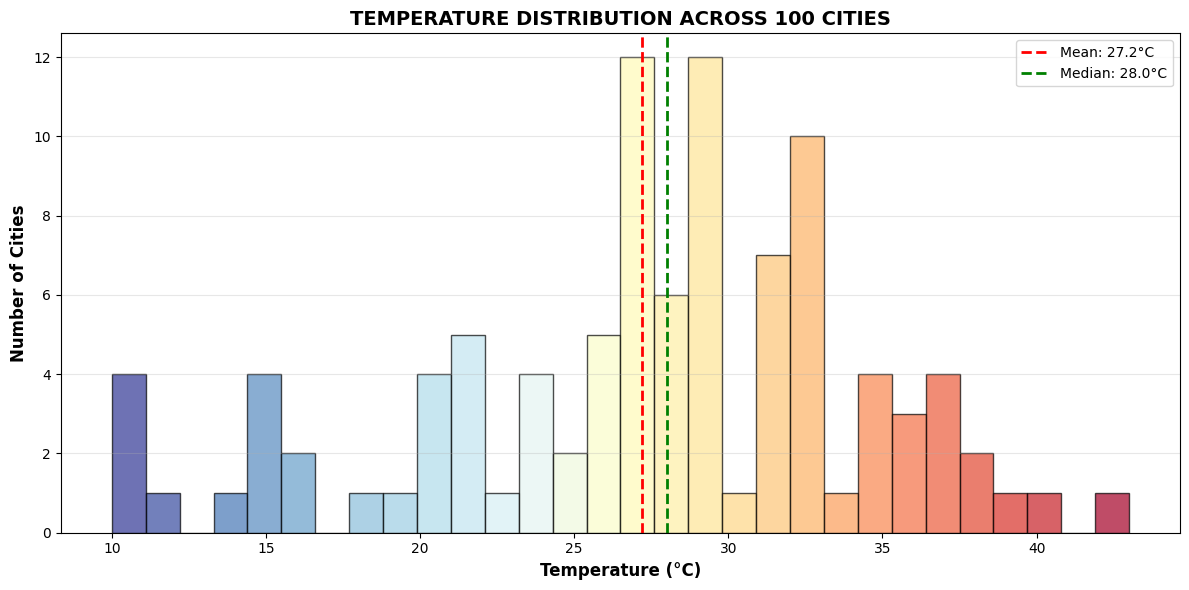

In [8]:
 #CELL 4: Visualization 3 - Temperature Distribution (Histogram)
# ============================================================
 
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(df['temperature'], bins=30, color='#45b7d1', edgecolor='black', alpha=0.7)
 
# Color gradient for bins
cm = plt.cm.RdYlBu_r
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))
 
plt.xlabel('Temperature (°C)', fontweight='bold', fontsize=12)
plt.ylabel('Number of Cities', fontweight='bold', fontsize=12)
plt.title('TEMPERATURE DISTRIBUTION ACROSS 100 CITIES', fontweight='bold', fontsize=14)
plt.axvline(df['temperature'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['temperature'].mean():.1f}°C")
plt.axvline(df['temperature'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {df['temperature'].median():.1f}°C")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

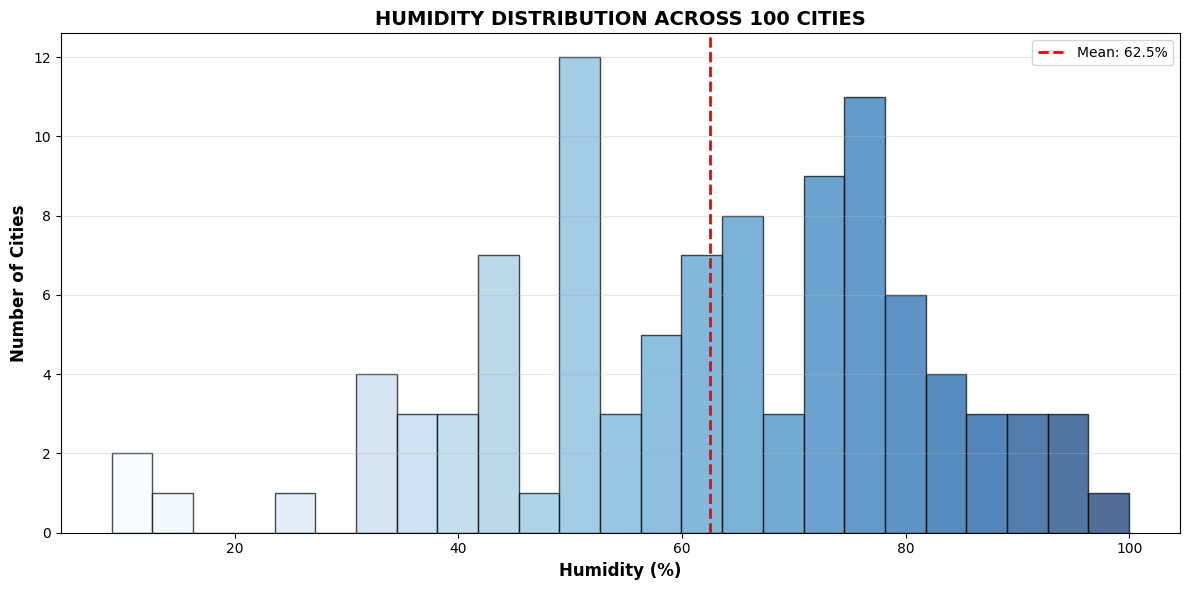

In [9]:
# CELL 5: Visualization 4 - Humidity Distribution (Histogram)
# ============================================================
 
plt.figure(figsize=(12, 6))
n, bins, patches = plt.hist(df['humidity'], bins=25, color='#95e1d3', edgecolor='black', alpha=0.7)
 
# Color gradient for bins
cm = plt.cm.Blues
bin_centers = 0.5 * (bins[:-1] + bins[1:])
col = bin_centers - min(bin_centers)
col /= max(col)
for c, p in zip(col, patches):
    plt.setp(p, 'facecolor', cm(c))
 
plt.xlabel('Humidity (%)', fontweight='bold', fontsize=12)
plt.ylabel('Number of Cities', fontweight='bold', fontsize=12)
plt.title('HUMIDITY DISTRIBUTION ACROSS 100 CITIES', fontweight='bold', fontsize=14)
plt.axvline(df['humidity'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['humidity'].mean():.1f}%")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

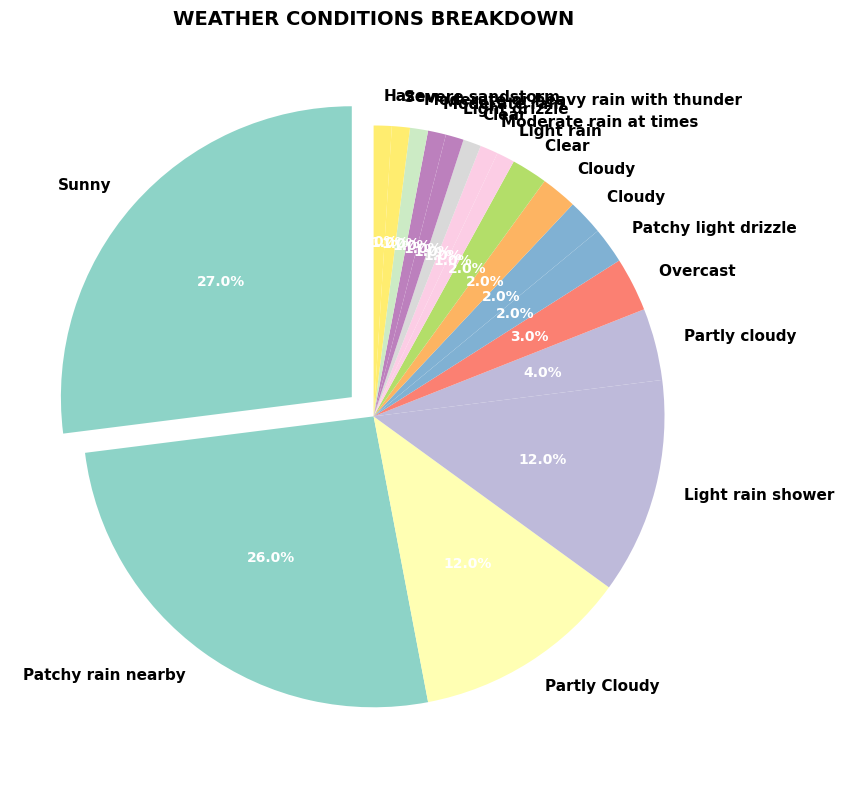

In [10]:
# CELL 6: Visualization 5 - Weather Conditions (Pie Chart)
# ============================================================
import numpy as np
plt.figure(figsize=(10, 8))
conditions = df['description'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(conditions)))
explode = [0.1 if i == 0 else 0 for i in range(len(conditions))]
 
wedges, texts, autotexts = plt.pie(conditions.values, 
                                     labels=conditions.index, 
                                     autopct='%1.1f%%',
                                     colors=colors,
                                     explode=explode,
                                     startangle=90,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'})
 
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
 
plt.title('WEATHER CONDITIONS BREAKDOWN', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

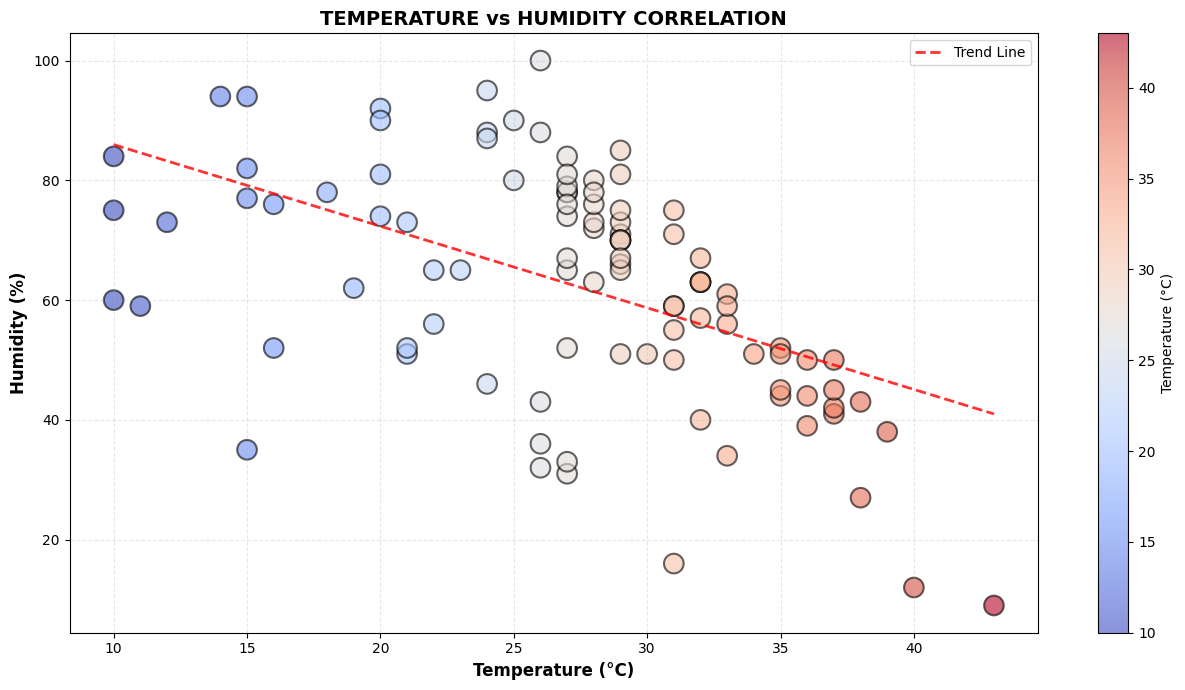

In [11]:
# CELL 7: Visualization 6 - Temperature vs Humidity (Scatter Plot)
# ============================================================
 
plt.figure(figsize=(13, 7))
scatter = plt.scatter(df['temperature'], df['humidity'], 
                     c=df['temperature'], cmap='coolwarm', 
                     s=200, alpha=0.6, edgecolors='black', linewidth=1.5)
 
plt.xlabel('Temperature (°C)', fontweight='bold', fontsize=12)
plt.ylabel('Humidity (%)', fontweight='bold', fontsize=12)
plt.title('TEMPERATURE vs HUMIDITY CORRELATION', fontweight='bold', fontsize=14)
cbar = plt.colorbar(scatter, label='Temperature (°C)')
plt.grid(True, alpha=0.3, linestyle='--')
 
# Add trend line
z = np.polyfit(df['temperature'], df['humidity'], 1)
p = np.poly1d(z)
plt.plot(df['temperature'].sort_values(), p(df['temperature'].sort_values()), 
         "r--", linewidth=2, label='Trend Line', alpha=0.8)
plt.legend()
 
plt.tight_layout()
plt.show()

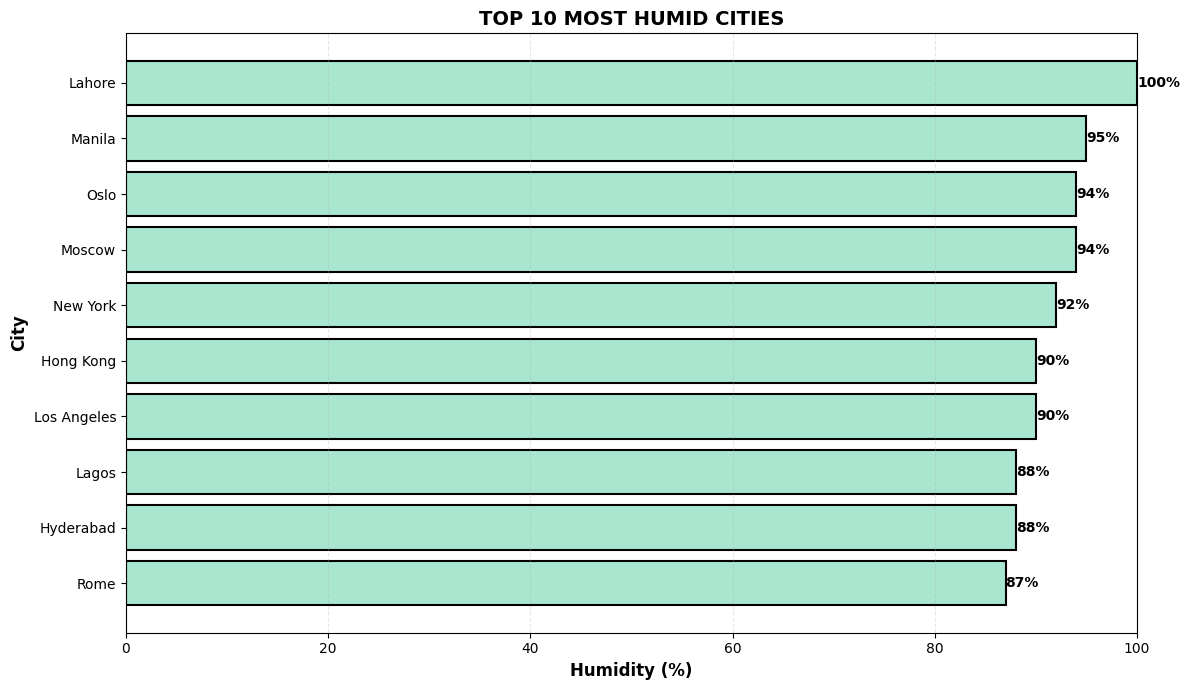

In [12]:
# CELL 8: Visualization 7 - Top 10 Most Humid Cities (Bar Chart)
# ============================================================
 
plt.figure(figsize=(12, 7))
top_humid = df.nlargest(10, 'humidity')[['city', 'humidity']].sort_values('humidity')
bars = plt.barh(top_humid['city'], top_humid['humidity'], color='#a8e6cf', edgecolor='black', linewidth=1.5)
 
# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width}%', 
             ha='left', va='center', fontweight='bold', fontsize=10)
 
plt.xlabel('Humidity (%)', fontweight='bold', fontsize=12)
plt.ylabel('City', fontweight='bold', fontsize=12)
plt.title('TOP 10 MOST HUMID CITIES', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

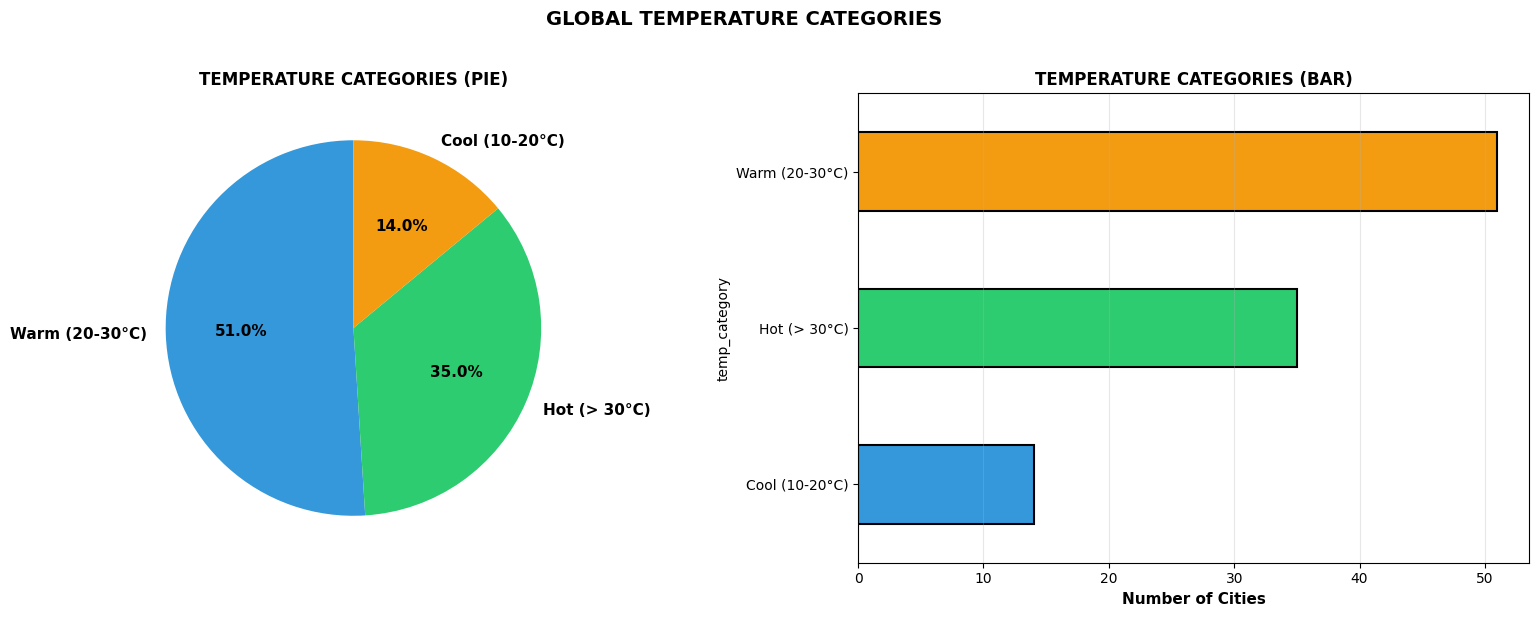

In [13]:
# CELL 9: Visualization 8 - Temperature Categories (Pie + Bar)
# ============================================================
 
# Categorize temperatures
def categorize_temp(temp):
    if temp < 0:
        return 'Freezing (< 0°C)'
    elif temp < 10:
        return 'Cold (0-10°C)'
    elif temp < 20:
        return 'Cool (10-20°C)'
    elif temp < 30:
        return 'Warm (20-30°C)'
    else:
        return 'Hot (> 30°C)'
 
df['temp_category'] = df['temperature'].apply(categorize_temp)
 
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
 
# Pie chart
categories = df['temp_category'].value_counts()
colors_cat = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
ax1.pie(categories.values, labels=categories.index, autopct='%1.1f%%',
        colors=colors_cat, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('TEMPERATURE CATEGORIES (PIE)', fontweight='bold', fontsize=12)
 
# Bar chart
categories.sort_values().plot(kind='barh', ax=ax2, color=colors_cat, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Number of Cities', fontweight='bold', fontsize=11)
ax2.set_title('TEMPERATURE CATEGORIES (BAR)', fontweight='bold', fontsize=12)
ax2.grid(axis='x', alpha=0.3)
 
plt.suptitle('GLOBAL TEMPERATURE CATEGORIES', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\vishn\AppData\Local\Temp\ipykernel_13952\3464676879.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1, 0].boxplot(temp_data, labels=regions, patch_artist=True)
C:\Users\vishn\AppData\Local\Temp\ipykernel_13952\3464676879.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(humidity_data, labels=regions, patch_artist=True)


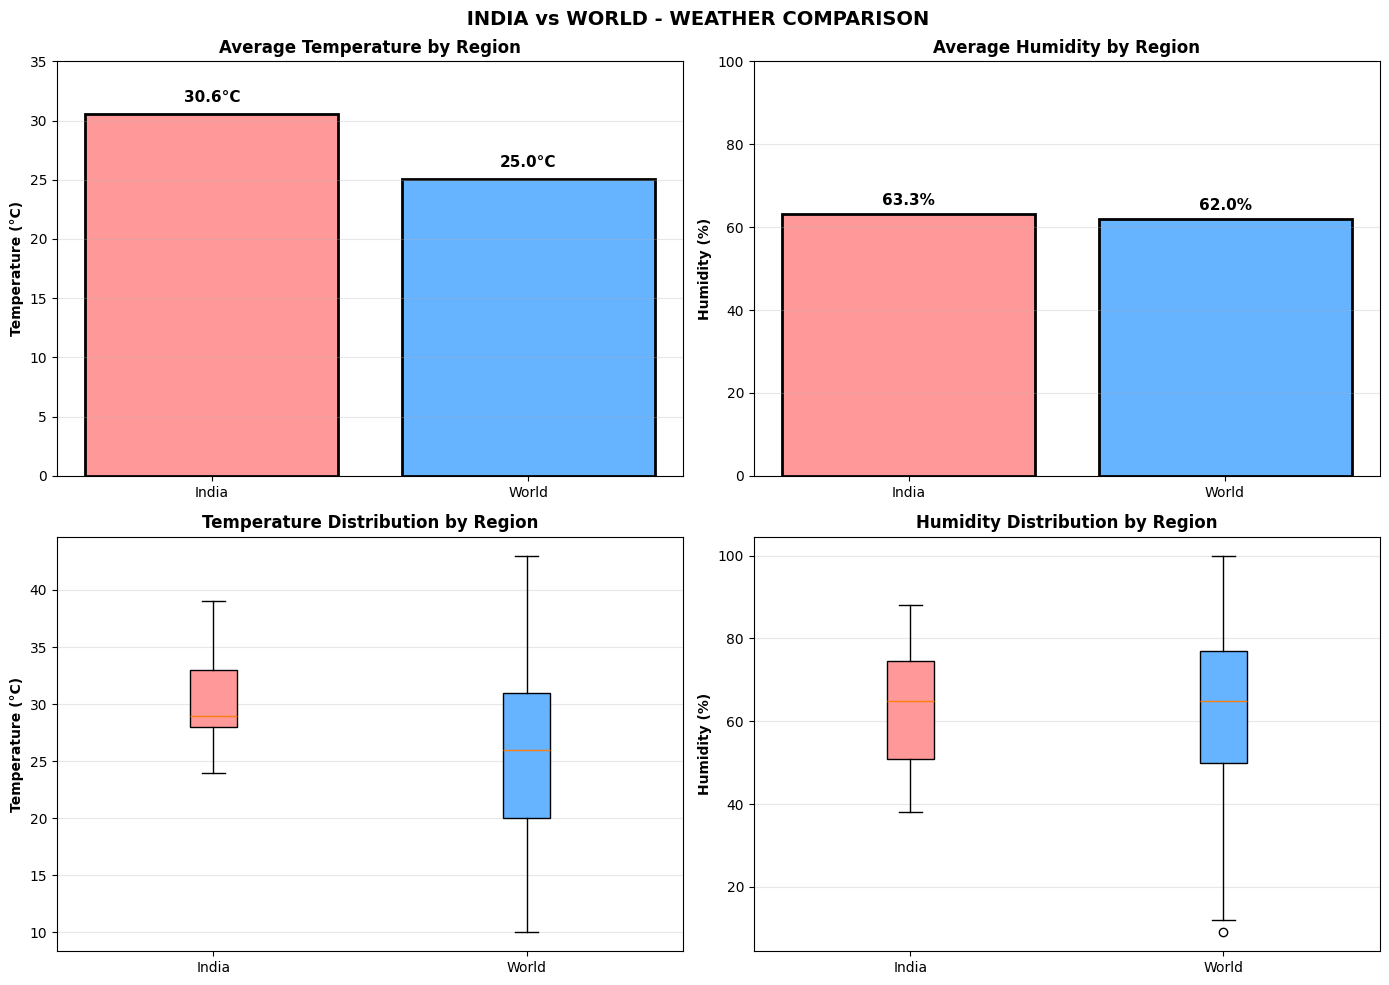

In [14]:
# CELL 10: Visualization 9 - India vs World Comparison
# ============================================================
 
# Separate India and World cities
india_cities = ['Thrissur', 'Kochi', 'Bangalore', 'Chennai', 'Mumbai', 'Delhi', 'Hyderabad', 'Pune',
                'Kolkata', 'Ahmedabad', 'Jaipur', 'Lucknow', 'Indore', 'Chandigarh', 'Surat',
                'Bhopal', 'Patna', 'Vadodara', 'Ghaziabad', 'Ludhiana', 'Visakhapatnam', 'Nagpur',
                'Coimbatore', 'Meerut', 'Nashik', 'Faridabad', 'Ranchi', 'Aurangabad', 'Kurnool',
                'Thiruvananthapuram', 'Guwahati', 'Mysore', 'Hubballi', 'Kozhikode', 'Ernakulam',
                'Kannur', 'Alappuzha', 'Malappuram', 'Palakkad']
 
df['region'] = df['city'].apply(lambda x: 'India' if x in india_cities else 'World')
 
# Calculate statistics
stats_by_region = df.groupby('region').agg({
    'temperature': ['min', 'max', 'mean'],
    'humidity': 'mean'
}).round(2)
 
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' INDIA vs WORLD - WEATHER COMPARISON', fontweight='bold', fontsize=14)
 
# Plot 1: Average Temperature
regions = ['India', 'World']
avg_temps = [df[df['region'] == r]['temperature'].mean() for r in regions]
colors_region = ['#ff9999', '#66b3ff']
axes[0, 0].bar(regions, avg_temps, color=colors_region, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Temperature (°C)', fontweight='bold')
axes[0, 0].set_title('Average Temperature by Region', fontweight='bold')
axes[0, 0].set_ylim(0, 35)
for i, v in enumerate(avg_temps):
    axes[0, 0].text(i, v + 1, f'{v:.1f}°C', ha='center', fontweight='bold', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)
 
# Plot 2: Average Humidity
avg_humidity = [df[df['region'] == r]['humidity'].mean() for r in regions]
axes[0, 1].bar(regions, avg_humidity, color=colors_region, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Humidity (%)', fontweight='bold')
axes[0, 1].set_title('Average Humidity by Region', fontweight='bold')
axes[0, 1].set_ylim(0, 100)
for i, v in enumerate(avg_humidity):
    axes[0, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)
 
# Plot 3: Box plot Temperature
temp_data = [df[df['region'] == r]['temperature'].values for r in regions]
bp1 = axes[1, 0].boxplot(temp_data, labels=regions, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_region):
    patch.set_facecolor(color)
axes[1, 0].set_ylabel('Temperature (°C)', fontweight='bold')
axes[1, 0].set_title('Temperature Distribution by Region', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
 
# Plot 4: Box plot Humidity
humidity_data = [df[df['region'] == r]['humidity'].values for r in regions]
bp2 = axes[1, 1].boxplot(humidity_data, labels=regions, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_region):
    patch.set_facecolor(color)
axes[1, 1].set_ylabel('Humidity (%)', fontweight='bold')
axes[1, 1].set_title('Humidity Distribution by Region', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.show()
 

# 📊 Final Weather Analytics Dashboard

The final dashboard combines multiple visualizations into a single interactive view, providing a comprehensive overview of weather patterns across 100 cities. It summarizes key weather metrics and highlights temperature, humidity, and weather condition trends to support quick analysis and decision-making.

### Dashboard Highlights

- 🌡️ **Top 10 Hottest Cities** – Displays the cities with the highest recorded temperatures.
- 📈 **Temperature Distribution** – Shows how temperature values are spread across the dataset.
- 💧 **Humidity Distribution** – Illustrates the frequency of humidity levels among all cities.
- ☁️ **Weather Conditions** – Visualizes the proportion of different weather conditions using a pie chart.
- 🔥 **Temperature vs Humidity** – Examines the relationship between temperature and humidity using a scatter plot.
- 💦 **Top Humid Cities** – Identifies cities with the highest humidity levels.
- 📋 **Key Metrics Panel** – Summarizes important statistics including minimum, maximum, average, and median values for temperature and humidity.

---

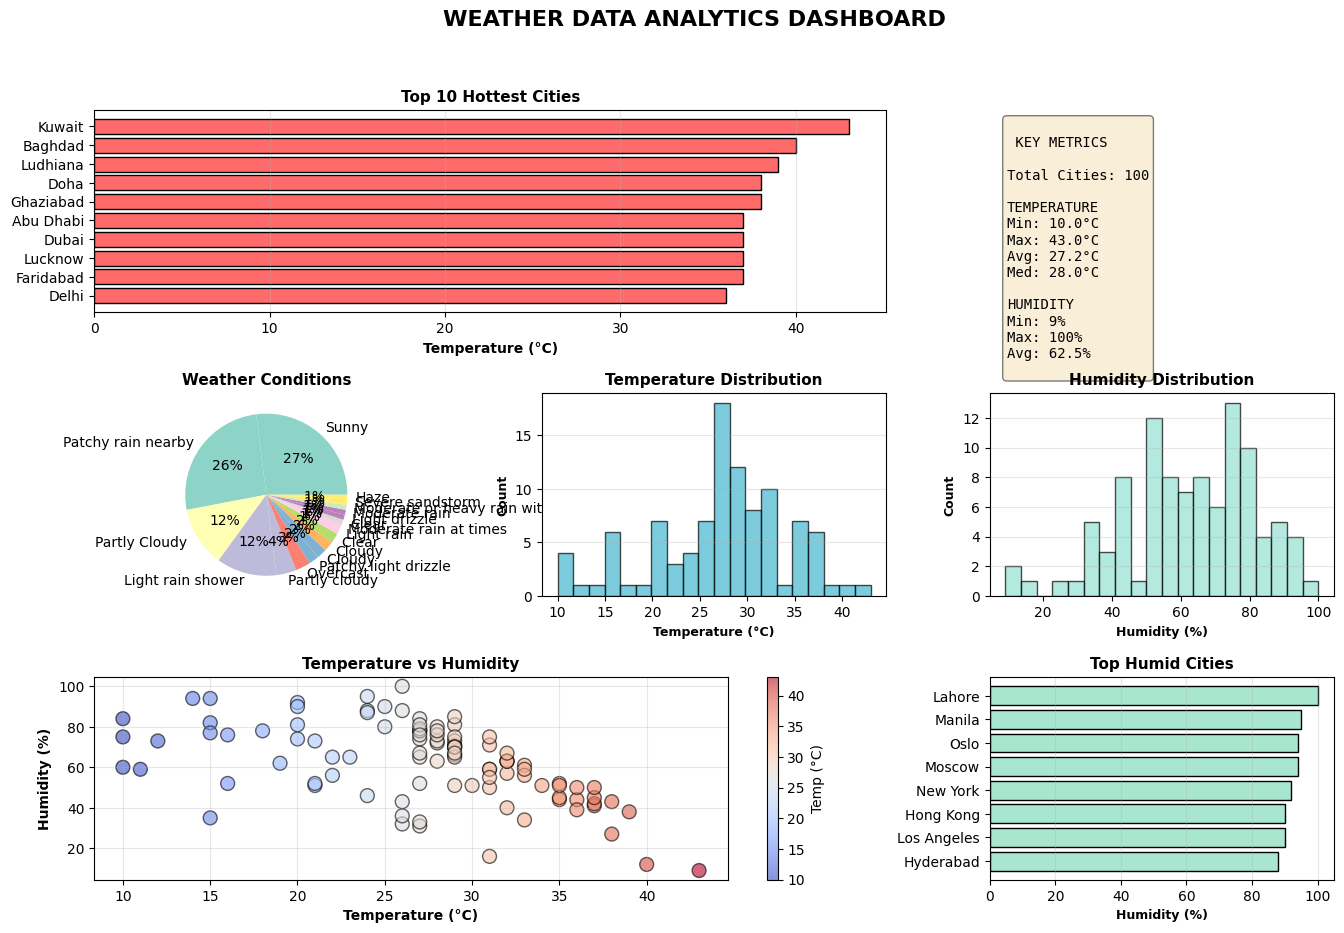

In [15]:
# CELL 11: Visualization 10 - Summary Statistics Dashboard
# ============================================================
 
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)
 
# Add title
fig.suptitle('WEATHER DATA ANALYTICS DASHBOARD', fontweight='bold', fontsize=16, y=0.98)
 
# 1. Temperature Range by City (Top 10)
ax1 = fig.add_subplot(gs[0, :2])
top_cities = df.nlargest(10, 'temperature')[['city', 'temperature']].sort_values('temperature')
ax1.barh(top_cities['city'], top_cities['temperature'], color='#ff6b6b', edgecolor='black', linewidth=1)
ax1.set_xlabel('Temperature (°C)', fontweight='bold')
ax1.set_title('Top 10 Hottest Cities', fontweight='bold', fontsize=11)
ax1.grid(axis='x', alpha=0.3)
 
# 2. Key Metrics
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('off')
metrics_text = f"""
 KEY METRICS
 
Total Cities: {len(df)}
 
TEMPERATURE
Min: {df['temperature'].min():.1f}°C
Max: {df['temperature'].max():.1f}°C
Avg: {df['temperature'].mean():.1f}°C
Med: {df['temperature'].median():.1f}°C
 
HUMIDITY
Min: {df['humidity'].min()}%
Max: {df['humidity'].max()}%
Avg: {df['humidity'].mean():.1f}%
"""
ax2.text(0.05, 0.95, metrics_text, transform=ax2.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
 
# 3. Weather Conditions
ax3 = fig.add_subplot(gs[1, 0])
conditions = df['description'].value_counts()
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(conditions)))
ax3.pie(conditions.values, labels=conditions.index, autopct='%1.0f%%', colors=colors_pie)
ax3.set_title('Weather Conditions', fontweight='bold', fontsize=11)
 
# 4. Temperature Distribution
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(df['temperature'], bins=20, color='#45b7d1', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Temperature (°C)', fontweight='bold', fontsize=9)
ax4.set_ylabel('Count', fontweight='bold', fontsize=9)
ax4.set_title('Temperature Distribution', fontweight='bold', fontsize=11)
ax4.grid(axis='y', alpha=0.3)
 
# 5. Humidity Distribution
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(df['humidity'], bins=20, color='#95e1d3', edgecolor='black', alpha=0.7)
ax5.set_xlabel('Humidity (%)', fontweight='bold', fontsize=9)
ax5.set_ylabel('Count', fontweight='bold', fontsize=9)
ax5.set_title('Humidity Distribution', fontweight='bold', fontsize=11)
ax5.grid(axis='y', alpha=0.3)
 
# 6. Scatter: Temp vs Humidity
ax6 = fig.add_subplot(gs[2, :2])
scatter = ax6.scatter(df['temperature'], df['humidity'], c=df['temperature'], 
                     cmap='coolwarm', s=100, alpha=0.6, edgecolors='black', linewidth=1)
ax6.set_xlabel('Temperature (°C)', fontweight='bold')
ax6.set_ylabel('Humidity (%)', fontweight='bold')
ax6.set_title('Temperature vs Humidity', fontweight='bold', fontsize=11)
ax6.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax6, label='Temp (°C)')
 
# 7. Top Humid Cities
ax7 = fig.add_subplot(gs[2, 2])
top_humid = df.nlargest(8, 'humidity')[['city', 'humidity']].sort_values('humidity', ascending=True)
ax7.barh(top_humid['city'], top_humid['humidity'], color='#a8e6cf', edgecolor='black', linewidth=1)
ax7.set_xlabel('Humidity (%)', fontweight='bold', fontsize=9)
ax7.set_title('Top Humid Cities', fontweight='bold', fontsize=11)
ax7.grid(axis='x', alpha=0.3)
 
plt.show()

In [16]:
# BONUS: Summary Statistics
# ============================================================
 
print("\n" + "="*80)
print("COMPREHENSIVE WEATHER DATA ANALYSIS SUMMARY")
print("="*80)
 
print("\nGEOGRAPHIC BREAKDOWN:")
print(f"   Total Cities: {len(df)}")
print(f"   India Cities: {len(df[df['region'] == 'India'])}")
print(f"   World Cities: {len(df[df['region'] == 'World'])}")
 
print("\nTEMPERATURE STATISTICS:")
print(f"   Minimum: {df['temperature'].min()}°C ({df.loc[df['temperature'].idxmin(), 'city']})")
print(f"   Maximum: {df['temperature'].max()}°C ({df.loc[df['temperature'].idxmax(), 'city']})")
print(f"   Average: {df['temperature'].mean():.2f}°C")
print(f"   Median: {df['temperature'].median():.2f}°C")
print(f"   Std Dev: {df['temperature'].std():.2f}°C")
 
print("\nHUMIDITY STATISTICS:")
print(f"   Minimum: {df['humidity'].min()}% ({df.loc[df['humidity'].idxmin(), 'city']})")
print(f"   Maximum: {df['humidity'].max()}% ({df.loc[df['humidity'].idxmax(), 'city']})")
print(f"   Average: {df['humidity'].mean():.2f}%")
print(f"   Median: {df['humidity'].median():.2f}%")
 
print("\nWEATHER CONDITIONS:")
for condition, count in df['description'].value_counts().items():
    print(f"   {condition}: {count} cities ({count/len(df)*100:.1f}%)")
 
print("\nINDIA vs WORLD:")
print(f"   India Avg Temp: {df[df['region'] == 'India']['temperature'].mean():.2f}°C")
print(f"   World Avg Temp: {df[df['region'] == 'World']['temperature'].mean():.2f}°C")
print(f"   India Avg Humidity: {df[df['region'] == 'India']['humidity'].mean():.2f}%")
print(f"   World Avg Humidity: {df[df['region'] == 'World']['humidity'].mean():.2f}%")
 
print("\n" + "="*80)


COMPREHENSIVE WEATHER DATA ANALYSIS SUMMARY

GEOGRAPHIC BREAKDOWN:
   Total Cities: 100
   India Cities: 39
   World Cities: 61

TEMPERATURE STATISTICS:
   Minimum: 10.0°C (Buenos Aires)
   Maximum: 43.0°C (Kuwait)
   Average: 27.21°C
   Median: 28.00°C
   Std Dev: 7.19°C

HUMIDITY STATISTICS:
   Minimum: 9% (Kuwait)
   Maximum: 100% (Lahore)
   Average: 62.51%
   Median: 65.00%

WEATHER CONDITIONS:
   Sunny: 27 cities (27.0%)
   Patchy rain nearby: 26 cities (26.0%)
   Partly Cloudy : 12 cities (12.0%)
   Light rain shower: 12 cities (12.0%)
   Partly cloudy: 4 cities (4.0%)
   Overcast : 3 cities (3.0%)
   Patchy light drizzle: 2 cities (2.0%)
   Cloudy : 2 cities (2.0%)
   Cloudy: 2 cities (2.0%)
   Clear : 2 cities (2.0%)
   Light rain: 1 cities (1.0%)
   Moderate rain at times: 1 cities (1.0%)
   Clear: 1 cities (1.0%)
   Light drizzle: 1 cities (1.0%)
   Moderate rain: 1 cities (1.0%)
   Moderate or heavy rain with thunder: 1 cities (1.0%)
   Severe sandstorm: 1 cities (1.0%)
  



# 📌 Conclusion

This project demonstrates the complete workflow of a weather data pipeline, from collecting raw weather data through an API to cleaning, transforming, analyzing, and visualizing the data. The dashboard provides a clear summary of weather patterns across multiple cities, enabling users to quickly identify temperature trends, humidity variations, and prevailing weather conditions.

Through this project, key data engineering and data analytics concepts such as API integration, data preprocessing, exploratory data analysis (EDA), and data visualization were successfully implemented using Python.

The resulting dataset and dashboard can serve as a foundation for future enhancements, including real-time weather monitoring, predictive weather forecasting, automated reporting, and interactive business intelligence dashboards using tools such as Power BI or Tableau.